# 🛰️ Classificação Automática de Modulação (AMC)
## Comparativo: CNN × SVM × KNN — Dataset RadioML2016.10a

---

**Objetivo:** Avaliar e comparar o desempenho de três abordagens de aprendizado de máquina para identificação automática de esquemas de modulação em sinais de rádio, simulando condições reais de canal (AWGN, desequilíbrio I/Q, CFO e desvanecimento).

| Algoritmo | Paradigma | Entrada |
|-----------|-----------|--------|
| CNN | Deep Learning | Dados brutos I/Q |
| SVM | Machine Learning clássico | Features extraídas |
| KNN | Machine Learning clássico | Features extraídas |

**Dataset:** RadioML2016.10a — 11 classes de modulação, SNR de -20 dB a +18 dB, 128 amostras complexas por segmento.

---
## 📦 BLOCO 1 — Instalação e Importação de Dependências

## Execução local no VS Code (versão adaptada)

Esta cópia remove as dependências do Google Colab, lê o dataset de `data/RML2016_10a_dict.pkl`, salva artefatos em `outputs/` e verifica se o TensorFlow detectou uma GPU.

Antes de executar, crie/ative o ambiente Python e instale as dependências conforme o arquivo `README_EXECUCAO_LOCAL.md`.


In [1]:
# Dependências devem ser instaladas no terminal do VS Code.
# Consulte README_EXECUCAO_LOCAL.md.
print('✅ Use o ambiente virtual selecionado no VS Code antes de executar o notebook.')

import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU configurada:", gpus)
    except RuntimeError as error:
        print("Erro ao configurar a GPU:", error)
else:
    print("Nenhuma GPU detectada.")

✅ Use o ambiente virtual selecionado no VS Code antes de executar o notebook.


2026-06-28 14:30:29.088297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU configurada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from pathlib import Path
import shutil

# Scikit-learn
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Google Colab

# Configurações gerais
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        # Evita que o TensorFlow reserve toda a VRAM imediatamente.
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as exc:
        print(f'⚠️ Não foi possível configurar memory growth: {exc}')

print(f'✅ TensorFlow: {tf.__version__}')
print(f'✅ Diretório do projeto: {PROJECT_DIR}')
print(f'✅ Diretório de saída: {OUTPUT_DIR}')
print(f'✅ GPUs disponíveis: {gpus}')
if not gpus:
    print('⚠️ TensorFlow não detectou GPU; a CNN será executada na CPU.')
print('✅ Todas as bibliotecas carregadas com sucesso.')

✅ TensorFlow: 2.20.0
✅ Diretório do projeto: /mnt/c/Users/Usuário/Projetos/IFCE
✅ Diretório de saída: /mnt/c/Users/Usuário/Projetos/IFCE/outputs
✅ GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Todas as bibliotecas carregadas com sucesso.


---
## ⚙️ BLOCO 2 — Configuração Global do Experimento

> **Edite este bloco** para ajustar as modulações de interesse, faixa de SNR, e hiperparâmetros de cada algoritmo.

In [3]:
# =============================================================
#  CONFIGURAÇÕES GLOBAIS — edite conforme necessário
# =============================================================

# Subconjunto de modulações para o experimento
# Todas disponíveis: ['8PSK','AM-DSB','AM-SSB','BPSK','CPFSK',
#                     'GFSK','PAM4','QAM16','QAM64','QPSK','WBFM']
MODULATIONS_OF_INTEREST = ['AM-DSB', 'WBFM', 'BPSK', 'QPSK', 'QAM16']

# Faixa de SNR a considerar (valores disponíveis: -20 a 18, passo 2)
SNR_MIN = -20
SNR_MAX = 18

# Divisão treino/teste
TRAIN_RATIO = 0.75

# ---- Hiperparâmetros CNN ----
CNN_FILTERS      = [60, 60, 60]       # filtros por camada conv
CNN_KERNELS      = [7, 5, 5]          # tamanho de kernel por camada
CNN_DROPOUT      = 0.3
CNN_LR           = 0.001
CNN_EPOCHS       = 60
CNN_BATCH_SIZE   = 256

# ---- Hiperparâmetros KNN ----
KNN_K            = 7                  # número de vizinhos
KNN_METRIC       = 'euclidean'

# ---- Hiperparâmetros SVM ----
SVM_C            = 1.0
SVM_CV_FOLDS     = 5                 # k-fold cross-validation

print('✅ Configurações carregadas:')
print(f'   Modulações : {MODULATIONS_OF_INTEREST}')
print(f'   SNR range  : {SNR_MIN} dB → {SNR_MAX} dB')
print(f'   Treino/Teste: {int(TRAIN_RATIO*100)}% / {int((1-TRAIN_RATIO)*100)}%')

✅ Configurações carregadas:
   Modulações : ['AM-DSB', 'WBFM', 'BPSK', 'QPSK', 'QAM16']
   SNR range  : -20 dB → 18 dB
   Treino/Teste: 75% / 25%


---
## 📂 BLOCO 3 — Carregamento do Dataset RadioML2016.10a

**Opções:**
- **Opção A (recomendada):** Faça o upload manual do arquivo `RML2016.10a_dict.pkl`
- **Opção B:** Geração de dados sintéticos para testes rápidos sem o dataset original

In [4]:
# =============================================================
#  BLOCO 3 — Carregamento local do Dataset RadioML2016.10a
# =============================================================

import pickle

# Estrutura esperada:
# projeto/
# ├── AMC_RadioML_Local_GPU.ipynb
# ├── data/
# │   └── RML2016_10a_dict.pkl
# └── outputs/
DATASET_PATH = PROJECT_DIR / 'data' / 'RML2016_10a_dict.pkl'

print(f'📂 Carregando dataset de:\n   {DATASET_PATH.resolve()}')
assert DATASET_PATH.exists(), (
    f'❌ Arquivo não encontrado: {DATASET_PATH.resolve()}\n'
    '   Crie a pasta data e coloque nela o arquivo RML2016_10a_dict.pkl.'
)

with DATASET_PATH.open('rb') as f:
    try:
        Xd = pickle.load(f, encoding='latin1')
    except TypeError:
        Xd = pickle.load(f)

print('✅ Dataset carregado com sucesso!')
print(f'   Combinações (mod, SNR) disponíveis : {len(Xd)}')
print(f'   Exemplo de chave                   : {list(Xd.keys())[0]}')
print(f'   Shape por entrada                  : {list(Xd.values())[0].shape}')
print(f'   Modulações únicas                  : {sorted(set(k[0] for k in Xd.keys()))}')
print(f'   SNRs disponíveis (dB)              : {sorted(set(k[1] for k in Xd.keys()))}')


📂 Carregando dataset de:
   /mnt/c/Users/Usuário/Projetos/IFCE/data/RML2016_10a_dict.pkl
✅ Dataset carregado com sucesso!
   Combinações (mod, SNR) disponíveis : 220
   Exemplo de chave                   : ('QPSK', 2)
   Shape por entrada                  : (1000, 2, 128)
   Modulações únicas                  : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
   SNRs disponíveis (dB)              : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [5]:
# =============================================================
#  OPÇÃO B — Gerador de dados sintéticos (fallback sem dataset)
# =============================================================
# Remove este bloco quando usar o dataset real (Opção A).

# def generate_synthetic_radioml(modulations, snr_range, n_samples=1000, seq_len=128):
#     """Gera sinais sintéticos com características básicas por modulação."""
#     Xd = {}
#     rng = np.random.default_rng(42)
#     mod_params = {
#         'BPSK':   lambda n: np.tile([1, -1], n//2 + 1)[:n] + 1j*0,
#         'QPSK':   lambda n: (rng.choice([1,-1], n) + 1j*rng.choice([1,-1], n)) / np.sqrt(2),
#         'QAM16':  lambda n: (rng.choice([-3,-1,1,3], n) + 1j*rng.choice([-3,-1,1,3], n)) / np.sqrt(10),
#         'AM-DSB': lambda n: np.cos(2*np.pi*0.1*np.arange(n)) * (1 + 0.5*np.cos(2*np.pi*0.02*np.arange(n))),
#         'WBFM':   lambda n: np.exp(1j * np.cumsum(rng.standard_normal(n) * 0.5)),
#     }
#     for mod in modulations:
#         for snr_db in range(snr_range[0], snr_range[1]+1, 2):
#             snr_lin = 10 ** (snr_db / 10.0)
#             noise_std = 1.0 / np.sqrt(2 * snr_lin)
#             gen = mod_params.get(mod, lambda n: rng.standard_normal(n) + 1j*rng.standard_normal(n))
#             samples = []
#             for _ in range(n_samples):
#                 s = gen(seq_len).astype(complex)
#                 noise = noise_std * (rng.standard_normal(seq_len) + 1j*rng.standard_normal(seq_len))
#                 s = s + noise
#                 samples.append(np.array([s.real, s.imag]))
#             Xd[(mod, snr_db)] = np.array(samples)
#     return Xd

# print('🔧 Gerando dados sintéticos (substitua pela Opção A para resultados reais)...')
# Xd = generate_synthetic_radioml(
#     MODULATIONS_OF_INTEREST,
#     snr_range=(SNR_MIN, SNR_MAX),
#     n_samples=500  # reduza para testes rápidos
# )
# print(f'✅ Dados sintéticos gerados: {len(Xd)} combinações (mod, SNR)')
# print(f'   Shape de exemplo: {list(Xd.values())[0].shape}  → (amostras, 2, 128)')

---
## 🔀 BLOCO 4 — Pré-processamento e Partição Treino/Teste

In [6]:
from sklearn.model_selection import train_test_split

def load_and_split(Xd, modulations, snr_min, snr_max, train_ratio=0.75):
    """
    Carrega os dados do dicionário RadioML, filtra modulações e SNRs,
    e retorna arrays particionados com estratificação pela combinação
    modulação–SNR, garantindo representação uniforme em treino e teste.
    """
    X_all, y_all, snr_all, strat_labels = [], [], [], []
    snr_range = range(snr_min, snr_max + 1, 2)

    for mod in modulations:
        for snr in snr_range:
            key = (mod, snr)
            if key not in Xd:
                continue
            data = Xd[key]                      # (N, 2, 128)
            n    = len(data)
            X_all.append(data)
            y_all.extend([mod] * n)
            snr_all.extend([snr] * n)
            # Rótulo composto para estratificação: "BPSK_-10", "QPSK_4", etc.
            strat_labels.extend([f'{mod}_{snr}'] * n)

    X_all        = np.vstack(X_all)
    y_all        = np.array(y_all)
    snr_all      = np.array(snr_all)
    strat_labels = np.array(strat_labels)

    le    = LabelEncoder()
    y_enc = le.fit_transform(y_all)

    # Divisão estratificada pelo rótulo composto (mod + SNR)
    X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
        X_all, y_enc, snr_all,
        test_size=1 - train_ratio,
        stratify=strat_labels,
        random_state=42
    )

    return X_train, X_test, y_train, y_test, snr_train, snr_test, le


X_train, X_test, y_train, y_test, snr_train, snr_test, le = load_and_split(
    Xd, MODULATIONS_OF_INTEREST, SNR_MIN, SNR_MAX, TRAIN_RATIO
)

# Verificação da estratificação
print('📊 Partição estratificada por modulação–SNR:')
print(f'   Treino : {X_train.shape} — {len(X_train)} amostras')
print(f'   Teste  : {X_test.shape}  — {len(X_test)} amostras')
print(f'   Classes: {le.classes_}')

print('\n📋 Distribuição por classe (treino vs teste):')
for cls_id, cls_name in enumerate(le.classes_):
    n_tr = (y_train == cls_id).sum()
    n_te = (y_test  == cls_id).sum()
    print(f'   {cls_name:<10} → treino: {n_tr:>5}  |  teste: {n_te:>5}  '
          f'|  ratio: {n_tr/(n_tr+n_te):.2f}')

print('\n📋 Distribuição por SNR (treino vs teste):')
for snr in sorted(set(snr_test)):
    n_tr = (snr_train == snr).sum()
    n_te = (snr_test  == snr).sum()
    print(f'   SNR {snr:>4} dB → treino: {n_tr:>5}  |  teste: {n_te:>5}  '
          f'|  ratio: {n_tr/(n_tr+n_te):.2f}')

📊 Partição estratificada por modulação–SNR:
   Treino : (75000, 2, 128) — 75000 amostras
   Teste  : (25000, 2, 128)  — 25000 amostras
   Classes: ['AM-DSB' 'BPSK' 'QAM16' 'QPSK' 'WBFM']

📋 Distribuição por classe (treino vs teste):
   AM-DSB     → treino: 15000  |  teste:  5000  |  ratio: 0.75
   BPSK       → treino: 15000  |  teste:  5000  |  ratio: 0.75
   QAM16      → treino: 15000  |  teste:  5000  |  ratio: 0.75
   QPSK       → treino: 15000  |  teste:  5000  |  ratio: 0.75
   WBFM       → treino: 15000  |  teste:  5000  |  ratio: 0.75

📋 Distribuição por SNR (treino vs teste):
   SNR  -20 dB → treino:  3750  |  teste:  1250  |  ratio: 0.75
   SNR  -18 dB → treino:  3750  |  teste:  1250  |  ratio: 0.75
   SNR  -16 dB → treino:  3750  |  teste:  1250  |  ratio: 0.75
   SNR  -14 dB → treino:  3750  |  teste:  1250  |  ratio: 0.75
   SNR  -12 dB → treino:  3750  |  teste:  1250  |  ratio: 0.75
   SNR  -10 dB → treino:  3750  |  teste:  1250  |  ratio: 0.75
   SNR   -8 dB → treino: 

In [7]:
# ---- Preparação dos formatos de entrada por algoritmo ----

# CNN: (N, 128, 2) — canais I e Q como features temporais
X_train_cnn = np.transpose(X_train, (0, 2, 1)).astype(np.float32)
X_test_cnn  = np.transpose(X_test,  (0, 2, 1)).astype(np.float32)

# SVM / KNN: vetor achatado (N, 256)
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32)
X_test_flat  = X_test.reshape(len(X_test),   -1).astype(np.float32)

n_classes = len(le.classes_)
print(f'✅ Formatos preparados:')
print(f'   CNN  → X_train: {X_train_cnn.shape}')
print(f'   Flat → X_train: {X_train_flat.shape}')
print(f'   N.º classes: {n_classes}')

✅ Formatos preparados:
   CNN  → X_train: (75000, 128, 2)
   Flat → X_train: (75000, 256)
   N.º classes: 5


---
## 🧠 BLOCO 5 — Modelo CNN

In [8]:
def build_cnn(input_shape, n_classes,
              filters=CNN_FILTERS, kernels=CNN_KERNELS,
              dropout=CNN_DROPOUT, lr=CNN_LR):
    """
    CNN 1D para classificação de modulação.
    Arquitetura: Conv1D × 3 → GlobalAvgPool → Dense → Softmax
    """
    inp = keras.Input(shape=input_shape, name='iq_input')
    x = inp
    for f, k in zip(filters, kernels):
        x = layers.Conv1D(f, k, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inp, out, name='AMC_CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


cnn_model = build_cnn(
    input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2]),
    n_classes=n_classes
)
cnn_model.summary()

I0000 00:00:1782667895.215579    1151 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:2b:00.0, compute capability: 7.5


Model: "AMC_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ iq_input (InputLayer)           │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 60)        │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 60)        │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 60)        │        18,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 60)        │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 60)        │        18,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 60)        │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 60)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,129 (211.44 KB)

 Trainable params: 53,769 (210.04 KB)

 Non-trainable params: 360 (1.41 KB)

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

print('🚀 Treinando CNN...')
t0 = time.time()
history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)
cnn_train_time = time.time() - t0
print(f'\n✅ CNN treinada em {cnn_train_time:.1f}s')

🚀 Treinando CNN...
Epoch 1/60


2026-06-28 14:31:37.642551: I external/local_xla/xla/service/service.cc:163] XLA service 0x7161a4008260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-28 14:31:37.642588: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-06-28 14:31:37.743029: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-28 14:31:38.430626: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-28 14:31:40.458461: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[256,60,1,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,60,1,128]{3,2,1,0}, f32[60,60,1,5]{3,2,1,0}), window={size=1x5 pad=0_0x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_conf

 24/250 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3716 - loss: 1.3684

I0000 00:00:1782667904.982089    1889 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.5236 - loss: 0.9723 - val_accuracy: 0.2005 - val_loss: 2.6714 - learning_rate: 0.0010
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6089 - loss: 0.7965 - val_accuracy: 0.2007 - val_loss: 3.1353 - learning_rate: 0.0010
Epoch 3/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6218 - loss: 0.7674 - val_accuracy: 0.5465 - val_loss: 1.2551 - learning_rate: 0.0010
Epoch 4/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6273 - loss: 0.7550 - val_accuracy: 0.5038 - val_loss: 1.2290 - learning_rate: 0.0010
Epoch 5/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6288 - loss: 0.7489 - val_accuracy: 0.5113 - val_loss: 1.4137 - learning_rate: 0.0010
Epoch 6/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6307 - loss: 0.7475 - val_accuracy: 0.5795 - val_loss: 0.9387 - learning_rate: 0.0010
Epoch 7/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6349 - loss: 0.7372 - val_accur

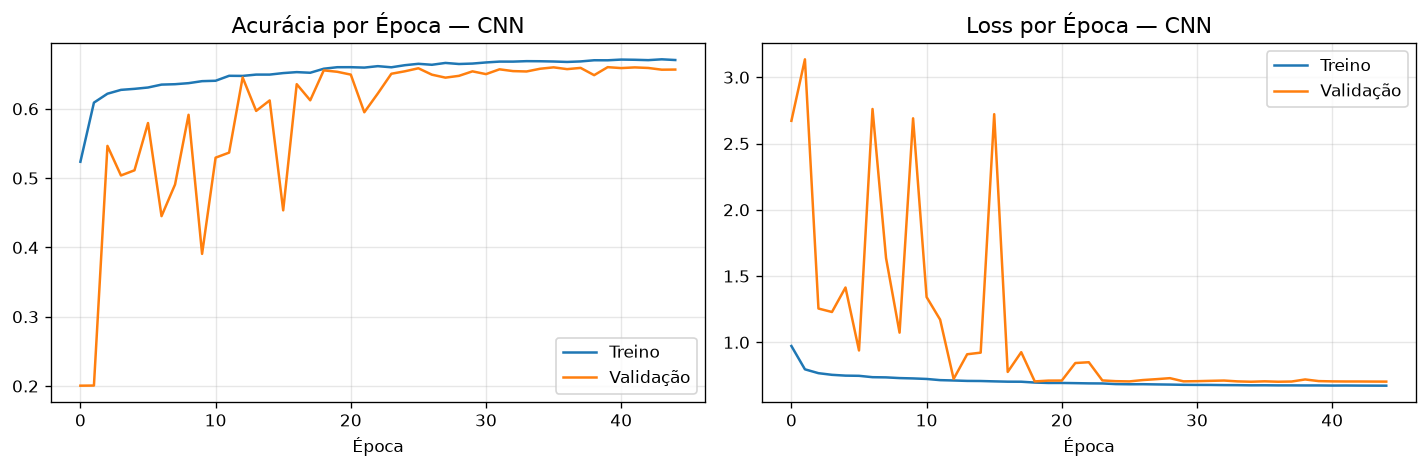

💾 Figura salva: cnn_learning_curves.png


In [10]:
# Curvas de aprendizado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes,
    ['accuracy', 'loss'],
    ['Acurácia por Época — CNN', 'Loss por Época — CNN']):
    ax.plot(history.history[metric],       label='Treino')
    ax.plot(history.history[f'val_{metric}'], label='Validação')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Época')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_learning_curves.png', bbox_inches='tight')
plt.show()
print('💾 Figura salva: cnn_learning_curves.png')

---
## 🌳 BLOCO 6 — Modelos KNN e SVM

In [11]:
# =============================================================
#  BLOCO 6 — KNN e SVM com Order-Statistics (Han et al., 2016)
# =============================================================

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import time

# -------------------------------------------------------------
# Extração de Order-Statistics (baseada em Han et al., 2016)
# -------------------------------------------------------------
def extract_order_statistics(X_iq):
    """
    Extrai e ordena 4 features por amostra, conforme Han et al. (2016):
      - Amplitude  η(k) = |r(k)|
      - Fase       ϑ(k) = ∠r(k)
      - Parte real x(k) = Re(r(k))
      - Parte imag y(k) = Im(r(k))

    Cada feature é normalizada pela sua std e depois ordenada
    (order-statistics). As 4 sequências ordenadas são concatenadas,
    resultando em shape (N, 4 × 128).

    Parâmetro:
        X_iq : np.ndarray de shape (N, 2, 128)  — canais I e Q
    Retorna:
        np.ndarray de shape (N, 512)
    """
    I = X_iq[:, 0, :]   # (N, 128)
    Q = X_iq[:, 1, :]   # (N, 128)

    amplitude  = np.sqrt(I**2 + Q**2)
    phase      = np.arctan2(Q, I)
    real_part  = I
    imag_part  = Q

    features = []
    for feat in [amplitude, phase, real_part, imag_part]:
        # Normalização por potência de cada amostra (canal desconhecido)
        std = feat.std(axis=1, keepdims=True) + 1e-8
        feat_norm = feat / std
        # Ordenação → order-statistics
        feat_sorted = np.sort(feat_norm, axis=1)
        features.append(feat_sorted)

    return np.concatenate(features, axis=1)   # (N, 512)


print('📐 Extraindo order-statistics...')
t0 = time.time()
X_train_os = extract_order_statistics(X_train)
X_test_os  = extract_order_statistics(X_test)
print(f'✅ Shape resultante: {X_train_os.shape}  ({time.time()-t0:.1f}s)')

# -------------------------------------------------------------
# KNN sobre Order-Statistics
# -------------------------------------------------------------
print(f'\n🚀 Treinando KNN (k={KNN_K}) sobre order-statistics...')
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=KNN_K,
                                    metric=KNN_METRIC,
                                    n_jobs=-1))
])
t0 = time.time()
knn_pipeline.fit(X_train_os, y_train)
knn_train_time = time.time() - t0
print(f'✅ KNN treinado em {knn_train_time:.1f}s')

print(f'\n📊 Cross-validation KNN ({SVM_CV_FOLDS}-fold)...')
cv_knn = cross_val_score(
    knn_pipeline,
    X_train_os,
    y_train,
    cv=StratifiedKFold(
        n_splits=SVM_CV_FOLDS,
        shuffle=True,
        random_state=42
    ),
    scoring='accuracy',
    n_jobs=1
)
print(f'   KNN CV: {cv_knn.mean():.4f} ± {cv_knn.std():.4f}')

# -------------------------------------------------------------
# LinearSVM sobre Order-Statistics (Han et al., 2016)
# -------------------------------------------------------------
print(f'\n🚀 Treinando LinearSVC sobre order-statistics...')
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C=SVM_C, max_iter=3000,
                         multi_class='ovr', random_state=42))
])
t0 = time.time()
svm_pipeline.fit(X_train_os, y_train)
svm_train_time = time.time() - t0
print(f'✅ LinearSVC treinado em {svm_train_time:.1f}s')

print(f'\n📊 Cross-validation LinearSVC ({SVM_CV_FOLDS}-fold)...')
cv_svm = cross_val_score(
    svm_pipeline,
    X_train_os,
    y_train,
    cv=StratifiedKFold(
        n_splits=SVM_CV_FOLDS,
        shuffle=True,
        random_state=42
    ),
    scoring='accuracy',
    n_jobs=1
)
print(f'   SVM CV: {cv_svm.mean():.4f} ± {cv_svm.std():.4f}')

📐 Extraindo order-statistics...
✅ Shape resultante: (75000, 512)  (0.8s)

🚀 Treinando KNN (k=7) sobre order-statistics...
✅ KNN treinado em 0.3s

📊 Cross-validation KNN (5-fold)...
   KNN CV: 0.5639 ± 0.0032

🚀 Treinando LinearSVC sobre order-statistics...
✅ LinearSVC treinado em 68.8s

📊 Cross-validation LinearSVC (5-fold)...
   SVM CV: 0.5472 ± 0.0051


In [12]:
# ---- KNN ----
# print(f'🚀 Treinando KNN (k={KNN_K}, métrica={KNN_METRIC})...')
# knn_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('knn',    KNeighborsClassifier(n_neighbors=KNN_K,
#                                     metric=KNN_METRIC,
#                                     n_jobs=-1))
# ])
# t0 = time.time()
# knn_pipeline.fit(X_train_flat, y_train)
# knn_train_time = time.time() - t0
# print(f'✅ KNN treinado em {knn_train_time:.1f}s')

# # Cross-validation KNN
# print('\n📊 Cross-validation KNN (5-fold)...')
# cv_knn = cross_val_score(knn_pipeline, X_train_flat, y_train,
#                           cv=StratifiedKFold(5), scoring='accuracy', n_jobs=-1)
# print(f'   KNN CV: {cv_knn.mean():.4f} ± {cv_knn.std():.4f}')

In [13]:
# ---- SVM ----
# print(f'🚀 Treinando SVM (kernel={SVM_KERNEL}, C={SVM_C})...')
# print('   ⚠️  SVM pode demorar em datasets grandes — aguarde...')

# svm_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svm',    LinearSVC(C=SVM_C, max_iter=2000, random_state=42))
# ])

# t0 = time.time()
# svm_pipeline.fit(X_train_flat, y_train)
# svm_train_time = time.time() - t0
# print(f'✅ SVM treinado em {svm_train_time:.1f}s')

# # Cross-validation SVM
# print(f'\n📊 Cross-validation SVM ({SVM_CV_FOLDS}-fold)...')
# cv_svm = cross_val_score(svm_pipeline, X_train_flat, y_train,
#                           cv=StratifiedKFold(SVM_CV_FOLDS), scoring='accuracy', n_jobs=-1)
# print(f'   SVM CV: {cv_svm.mean():.4f} ± {cv_svm.std():.4f}')

---
## 📊 BLOCO 7 — Avaliação Global e por SNR

In [14]:
def measure_inference_time(model, X, model_type='sklearn', n_runs=5):
    """Mede o tempo médio de inferência em ms por amostra."""
    times = []
    for _ in range(n_runs):
        t = time.perf_counter()
        if model_type == 'keras':
            model.predict(X, verbose=0)
        else:
            model.predict(X)
        times.append(time.perf_counter() - t)
    avg_ms = (np.mean(times) / len(X)) * 1000
    return avg_ms


# Acurácia global
y_pred_cnn = np.argmax(
    cnn_model.predict(
        X_test_cnn,
        batch_size=CNN_BATCH_SIZE,
        verbose=0
    ),
    axis=1
)
y_pred_knn = knn_pipeline.predict(X_test_os)
y_pred_svm = svm_pipeline.predict(X_test_os)

acc_cnn = accuracy_score(y_test, y_pred_cnn)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("=" * 40)
print(f"{'Algoritmo':<12}{'Acurácia':>12}")
print("=" * 40)
print(f"{'CNN':<12}{acc_cnn:>12.4f}")
print(f"{'KNN':<12}{acc_knn:>12.4f}")
print(f"{'LinearSVC':<12}{acc_svm:>12.4f}")
print("=" * 40)

Algoritmo       Acurácia
CNN               0.6536
KNN               0.5702
LinearSVC         0.5524


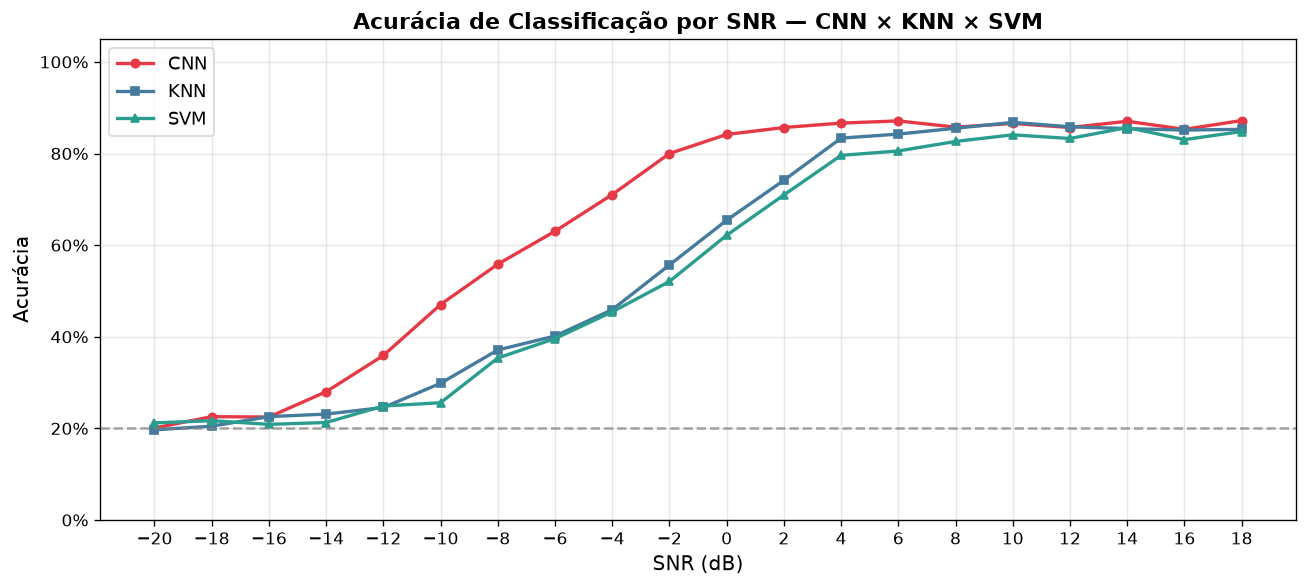

💾 Figura salva: accuracy_vs_snr.png


In [15]:
# Acurácia por SNR
snr_values = sorted(set(snr_test))
acc_by_snr = {name: [] for name in ['CNN', 'KNN', 'SVM']}

for snr in snr_values:
    mask = snr_test == snr
    if mask.sum() == 0:
        for name in acc_by_snr:
            acc_by_snr[name].append(np.nan)
        continue
    acc_by_snr['CNN'].append(accuracy_score(y_test[mask], y_pred_cnn[mask]))
    acc_by_snr['KNN'].append(accuracy_score(y_test[mask], y_pred_knn[mask]))
    acc_by_snr['SVM'].append(accuracy_score(y_test[mask], y_pred_svm[mask]))

# Gráfico Acurácia × SNR
fig, ax = plt.subplots(figsize=(11, 5))
colors  = {'CNN': '#E63946', 'KNN': '#457B9D', 'SVM': '#2A9D8F'}
markers = {'CNN': 'o', 'KNN': 's', 'SVM': '^'}

for name in ['CNN', 'KNN', 'SVM']:
    ax.plot(snr_values, acc_by_snr[name],
            label=name, color=colors[name],
            marker=markers[name], linewidth=2, markersize=5)

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Acurácia', fontsize=12)
ax.set_title('Acurácia de Classificação por SNR — CNN × KNN × SVM', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xticks(snr_values)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
chance_level = 1.0 / 5.0
ax.axhline(
    chance_level,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Classificação aleatória ({chance_level:.0%})"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_vs_snr.png', bbox_inches='tight')
plt.show()
print('💾 Figura salva: accuracy_vs_snr.png')

---
## 🔲 BLOCO 8 — Matrizes de Confusão

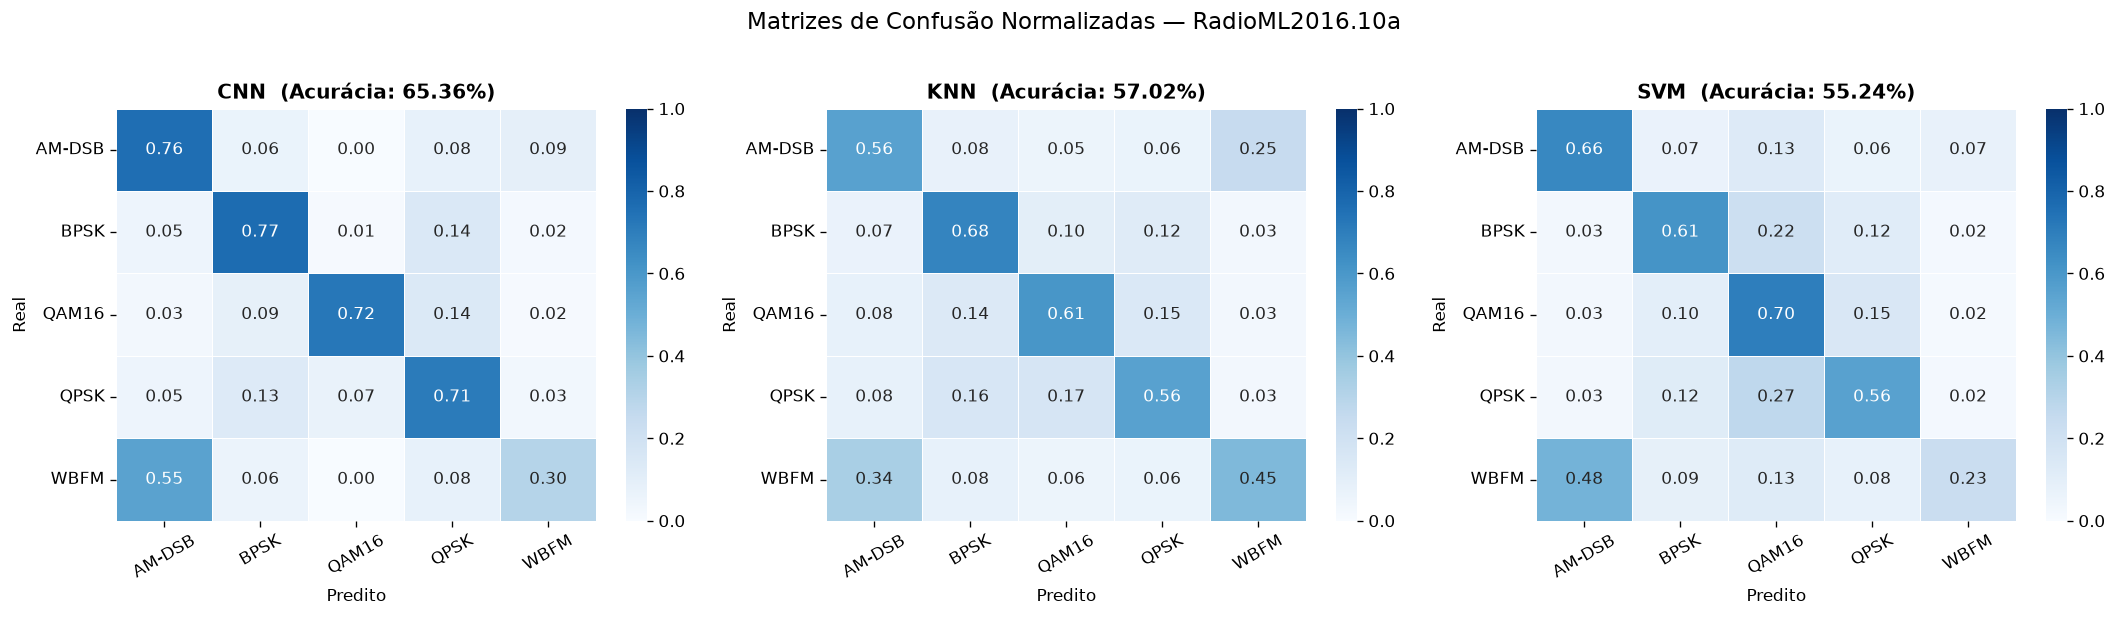

💾 Figura salva: confusion_matrices.png


In [16]:
def plot_confusion_matrix(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predito', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = le.classes_

plot_confusion_matrix(y_test, y_pred_cnn, class_names, f'CNN  (Acurácia: {acc_cnn:.2%})', axes[0])
plot_confusion_matrix(y_test, y_pred_knn, class_names, f'KNN  (Acurácia: {acc_knn:.2%})', axes[1])
plot_confusion_matrix(y_test, y_pred_svm, class_names, f'SVM  (Acurácia: {acc_svm:.2%})', axes[2])

plt.suptitle('Matrizes de Confusão Normalizadas — RadioML2016.10a', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()
print('💾 Figura salva: confusion_matrices.png')

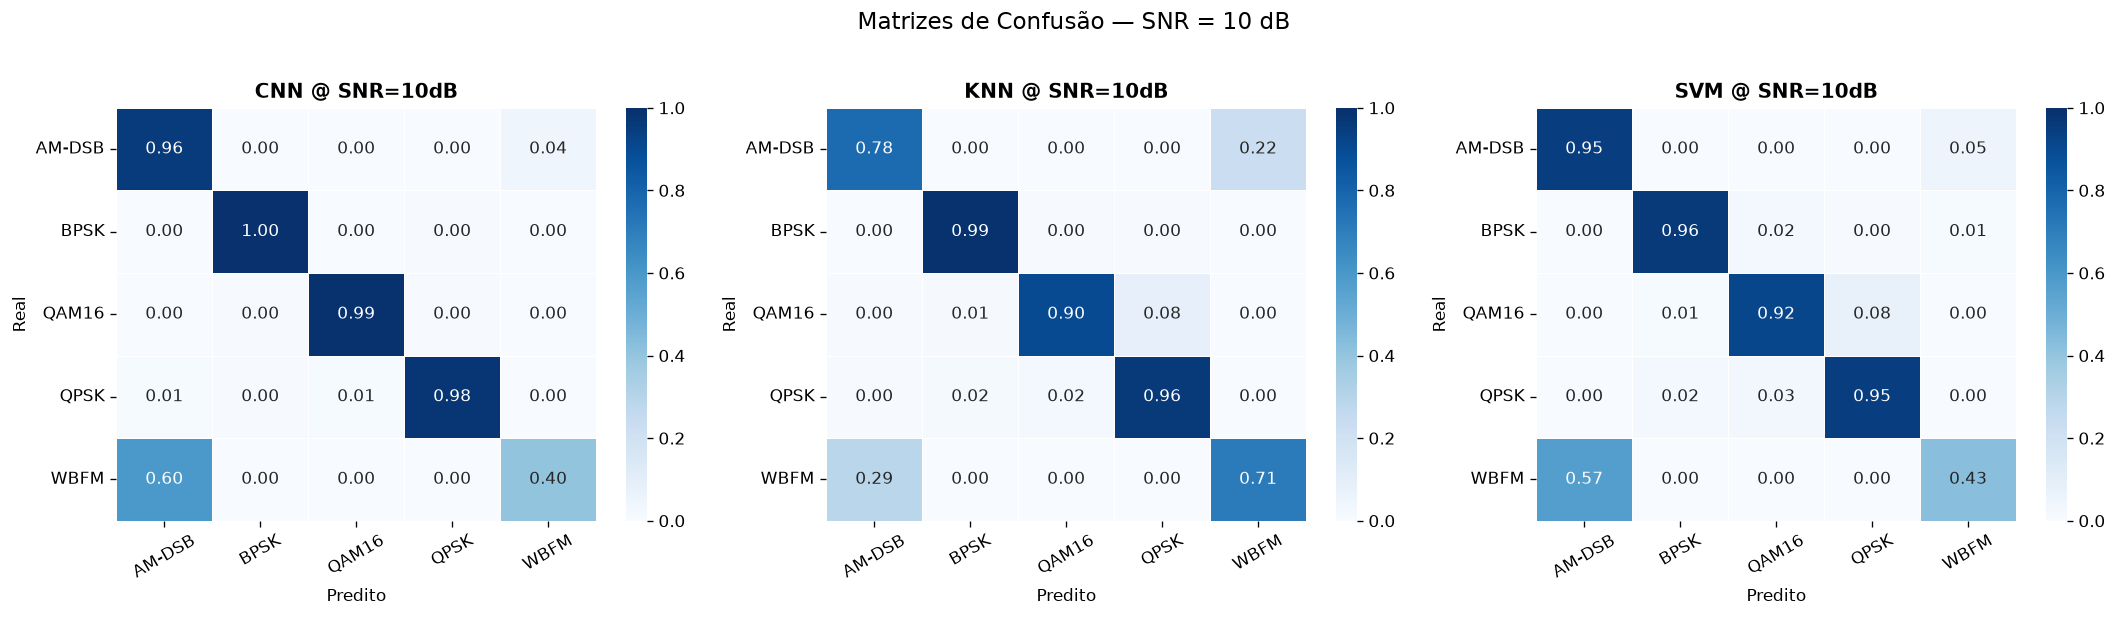

In [17]:
# Matriz de confusão por SNR específico (SNR alto: 10 dB)
TARGET_SNR = 10
mask_snr = snr_test == TARGET_SNR

if mask_snr.sum() > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plot_confusion_matrix(y_test[mask_snr], y_pred_cnn[mask_snr], class_names,
                          f'CNN @ SNR={TARGET_SNR}dB', axes[0])
    plot_confusion_matrix(y_test[mask_snr], y_pred_knn[mask_snr], class_names,
                          f'KNN @ SNR={TARGET_SNR}dB', axes[1])
    plot_confusion_matrix(y_test[mask_snr], y_pred_svm[mask_snr], class_names,
                          f'SVM @ SNR={TARGET_SNR}dB', axes[2])
    plt.suptitle(f'Matrizes de Confusão — SNR = {TARGET_SNR} dB', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'confusion_snr_{TARGET_SNR}dB.png', bbox_inches='tight')
    plt.show()
else:
    print(f'⚠️  Sem amostras de teste com SNR = {TARGET_SNR} dB.')

---
##BLOCO EXTRA - Complexidade computacional

In [18]:
# =============================================================
# COMPLEXIDADE COMPUTACIONAL E LATÊNCIA
# =============================================================

import time
import numpy as np
import pandas as pd
import tensorflow as tf

# -------------------------------------------------------------
# Parâmetros obtidos diretamente dos dados e dos modelos
# -------------------------------------------------------------
N_TRAIN = X_train_os.shape[0]       # 75.000
N_TEST = X_test_os.shape[0]         # 25.000
SEQ_LEN = X_train.shape[-1]         # K = 128
N_FEATURES = X_train_os.shape[1]    # D = 512
N_CLASSES = len(le.classes_)        # M = 5
N_RUNS = 10

assert N_FEATURES == 4 * SEQ_LEN, (
    f"Esperado D = 4K = {4 * SEQ_LEN}, "
    f"mas foram encontrados {N_FEATURES} atributos."
)

print("Configuração:")
print(f"  N de treinamento = {N_TRAIN}")
print(f"  N de teste       = {N_TEST}")
print(f"  K                = {SEQ_LEN}")
print(f"  D                = {N_FEATURES}")
print(f"  M                = {N_CLASSES}")
print(f"  GPU TensorFlow   = {tf.config.list_physical_devices('GPU')}")
print(f"  Busca do KNN     = "
      f"{knn_pipeline.named_steps['knn']._fit_method}")


# -------------------------------------------------------------
# Medição genérica de tempo
# -------------------------------------------------------------
def measure_callable_time(
    callable_function,
    n_samples,
    n_runs=10,
    warmup_runs=2
):
    """
    Mede o tempo médio por amostra.

    Parameters
    ----------
    callable_function:
        Função sem argumentos que executa a predição.
    n_samples:
        Número de exemplos processados em cada execução.
    n_runs:
        Número de execuções cronometradas.
    warmup_runs:
        Execuções iniciais não contabilizadas.

    Returns
    -------
    mean_ms, std_ms:
        Média e desvio padrão em milissegundos por amostra.
    """
    for _ in range(warmup_runs):
        callable_function()

    times_ms = []

    for _ in range(n_runs):
        start = time.perf_counter()
        callable_function()
        elapsed = time.perf_counter() - start

        times_ms.append(
            elapsed * 1000.0 / n_samples
        )

    return float(np.mean(times_ms)), float(np.std(times_ms))


# -------------------------------------------------------------
# Predição somente com os dados já preparados
# -------------------------------------------------------------
def predict_cnn_prepared():
    return cnn_model.predict(
        X_test_cnn,
        batch_size=CNN_BATCH_SIZE,
        verbose=0
    )


def predict_knn_prepared():
    return knn_pipeline.predict(X_test_os)


def predict_svm_prepared():
    return svm_pipeline.predict(X_test_os)


# -------------------------------------------------------------
# Predição completa a partir das amostras I/Q
# -------------------------------------------------------------
def predict_cnn_end_to_end():
    # Conversão de (N, 2, 128) para (N, 128, 2)
    X_input = np.transpose(
        X_test,
        (0, 2, 1)
    ).astype(np.float32, copy=False)

    return cnn_model.predict(
        X_input,
        batch_size=CNN_BATCH_SIZE,
        verbose=0
    )


def predict_knn_end_to_end():
    # Inclui cálculo, normalização e ordenação das quatro sequências
    X_features = extract_order_statistics(X_test)
    return knn_pipeline.predict(X_features)


def predict_svm_end_to_end():
    # Inclui cálculo, normalização e ordenação das quatro sequências
    X_features = extract_order_statistics(X_test)
    return svm_pipeline.predict(X_features)


# -------------------------------------------------------------
# Latência com entradas já preparadas
# -------------------------------------------------------------
print("\nMedindo latência somente dos classificadores...")

cnn_core_mean, cnn_core_std = measure_callable_time(
    predict_cnn_prepared,
    N_TEST,
    n_runs=N_RUNS
)

knn_core_mean, knn_core_std = measure_callable_time(
    predict_knn_prepared,
    N_TEST,
    n_runs=N_RUNS
)

svm_core_mean, svm_core_std = measure_callable_time(
    predict_svm_prepared,
    N_TEST,
    n_runs=N_RUNS
)


# -------------------------------------------------------------
# Latência completa
# -------------------------------------------------------------
print("Medindo latência completa, incluindo pré-processamento...")

cnn_e2e_mean, cnn_e2e_std = measure_callable_time(
    predict_cnn_end_to_end,
    N_TEST,
    n_runs=N_RUNS
)

knn_e2e_mean, knn_e2e_std = measure_callable_time(
    predict_knn_end_to_end,
    N_TEST,
    n_runs=N_RUNS
)

svm_e2e_mean, svm_e2e_std = measure_callable_time(
    predict_svm_end_to_end,
    N_TEST,
    n_runs=N_RUNS
)


# -------------------------------------------------------------
# Estimativa das operações da CNN
# -------------------------------------------------------------
def estimate_cnn_macs(model):
    """
    Estima as operações multiply-accumulate (MACs) das camadas
    Conv1D e Dense.

    Não inclui BatchNormalization, ativações, pooling, dropout
    e softmax.
    """
    total_macs = 0
    details = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv1D):
            output_length = int(layer.output.shape[1])
            output_channels = int(layer.output.shape[2])
            input_channels = int(layer.input.shape[-1])
            kernel_size = int(layer.kernel_size[0])

            layer_macs = (
                output_length
                * output_channels
                * input_channels
                * kernel_size
            )

            total_macs += layer_macs
            details.append((layer.name, layer_macs))

        elif isinstance(layer, tf.keras.layers.Dense):
            input_units = int(layer.input.shape[-1])
            output_units = int(layer.units)

            layer_macs = input_units * output_units

            total_macs += layer_macs
            details.append((layer.name, layer_macs))

    return total_macs, details


cnn_macs, cnn_macs_details = estimate_cnn_macs(cnn_model)
cnn_params = cnn_model.count_params()


# -------------------------------------------------------------
# Estimativas para KNN, SVM e extração das características
# -------------------------------------------------------------

# KNN: uma contribuição de distância por atributo e amostra
# de treinamento. Não inclui a seleção dos k menores valores.
knn_distance_terms = N_TRAIN * N_FEATURES

# LinearSVC OvR: um produto interno de D atributos para cada classe.
svm_macs = N_CLASSES * N_FEATURES

# Quatro ordenações de sequências com K elementos.
order_stats_sort_terms = (
    4 * SEQ_LEN * np.log2(SEQ_LEN)
)


# -------------------------------------------------------------
# Tabela final
# -------------------------------------------------------------
complexity_results = pd.DataFrame({
    "Algoritmo": [
        "CNN",
        "KNN",
        "LinearSVC"
    ],
    "Dispositivo": [
        "GPU",
        "CPU",
        "CPU"
    ],
    "Representação": [
        f"I/Q: {SEQ_LEN} × 2",
        f"Order-statistics: D={N_FEATURES}",
        f"Order-statistics: D={N_FEATURES}"
    ],
    "Tamanho/Operações do classificador": [
        (
            f"{cnn_params:,} parâmetros; "
            f"{cnn_macs:,} MACs"
        ),
        (
            f"{knn_distance_terms:,} "
            "termos de distância/amostra"
        ),
        (
            f"{svm_macs:,} MACs/amostra"
        )
    ],
    "Complexidade de inferência": [
        "Dependente da arquitetura da rede",
        "O(ND)",
        "O(MD)"
    ],
    "Latência classificador (ms/amostra)": [
        f"{cnn_core_mean:.6f} ± {cnn_core_std:.6f}",
        f"{knn_core_mean:.6f} ± {knn_core_std:.6f}",
        f"{svm_core_mean:.6f} ± {svm_core_std:.6f}"
    ],
    "Latência completa (ms/amostra)": [
        f"{cnn_e2e_mean:.6f} ± {cnn_e2e_std:.6f}",
        f"{knn_e2e_mean:.6f} ± {knn_e2e_std:.6f}",
        f"{svm_e2e_mean:.6f} ± {svm_e2e_std:.6f}"
    ]
}).set_index("Algoritmo")

print("\n" + "=" * 100)
print("RELATÓRIO CORRIGIDO DE COMPLEXIDADE")
print("=" * 100)
print(complexity_results.to_string())
print("=" * 100)

print("\nExtração das estatísticas de ordem:")
print(
    f"  4 × K × log2(K) ≈ "
    f"{order_stats_sort_terms:,.0f} termos de ordenação/amostra"
)
print("  Complexidade assintótica: O(4K log K)")

print("\nDetalhamento dos MACs da CNN:")
for layer_name, layer_macs in cnn_macs_details:
    print(f"  {layer_name:<25}: {layer_macs:>12,} MACs")

print(f"  Total Conv1D + Dense      : {cnn_macs:>12,} MACs")

print("\nObservações:")
print("  - A latência do classificador usa os dados já preparados.")
print("  - A latência completa inclui a preparação das entradas.")
print("  - A CNN é executada pelo TensorFlow em GPU.")
print("  - KNN, LinearSVC, StandardScaler e NumPy utilizam CPU.")
print("  - As estimativas de operações não são diretamente")
print("    equivalentes ao tempo, pois os dispositivos são diferentes.")


# Salva os resultados
complexity_results.to_csv(
    OUTPUT_DIR / "complexidade_corrigida.csv"
)

print(
    "\nArquivo salvo:",
    OUTPUT_DIR / "complexidade_corrigida.csv"
)

Configuração:
  N de treinamento = 75000
  N de teste       = 25000
  K                = 128
  D                = 512
  M                = 5
  GPU TensorFlow   = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  Busca do KNN     = brute

Medindo latência somente dos classificadores...
Medindo latência completa, incluindo pré-processamento...

RELATÓRIO CORRIGIDO DE COMPLEXIDADE
          Dispositivo            Representação      Tamanho/Operações do classificador         Complexidade de inferência Latência classificador (ms/amostra) Latência completa (ms/amostra)
Algoritmo                                                                                                                                                                                   
CNN               GPU             I/Q: 128 × 2       54,129 parâmetros; 4,731,712 MACs  Dependente da arquitetura da rede                 0.011563 ± 0.000624            0.011050 ± 0.000119
KNN               CPU  Order-stat

---
## ⏱️ BLOCO 9 — Métricas de Complexidade e Relatório Final

In [19]:
# ---- Relatório de classificação detalhado ----
for name, y_pred in [('CNN', y_pred_cnn), ('KNN', y_pred_knn), ('SVM', y_pred_svm)]:
    print('\n' + '='*55)
    print(f'  Relatório de Classificação — {name}')
    print('='*55)
    print(classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                digits=4))



  Relatório de Classificação — CNN
              precision    recall  f1-score   support

      AM-DSB     0.5264    0.7600    0.6220      5000
        BPSK     0.6900    0.7692    0.7274      5000
       QAM16     0.8885    0.7238    0.7978      5000
        QPSK     0.6123    0.7116    0.6582      5000
        WBFM     0.6526    0.3032    0.4140      5000

    accuracy                         0.6536     25000
   macro avg     0.6740    0.6536    0.6439     25000
weighted avg     0.6740    0.6536    0.6439     25000


  Relatório de Classificação — KNN
              precision    recall  f1-score   support

      AM-DSB     0.4929    0.5556    0.5224      5000
        BPSK     0.5961    0.6766    0.6338      5000
       QAM16     0.6113    0.6078    0.6096      5000
        QPSK     0.5862    0.5584    0.5720      5000
        WBFM     0.5719    0.4524    0.5052      5000

    accuracy                         0.5702     25000
   macro avg     0.5717    0.5702    0.5686     25000
weigh

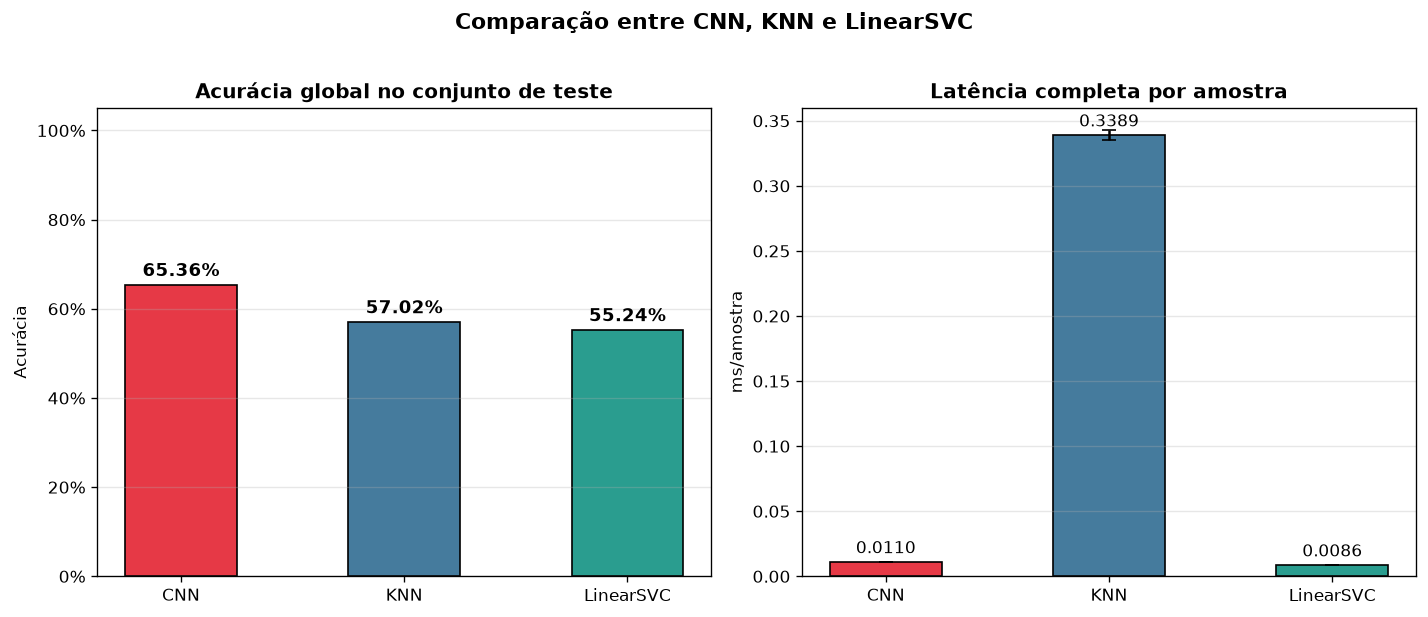

💾 Figura salva: comparativo_final.png


In [20]:
# =============================================================
# GRÁFICO FINAL: ACURÁCIA E LATÊNCIA COMPLETA
# =============================================================

algorithms = ["CNN", "KNN", "LinearSVC"]

accuracies = [
    acc_cnn,
    acc_knn,
    acc_svm
]

latency_means = [
    cnn_e2e_mean,
    knn_e2e_mean,
    svm_e2e_mean
]

latency_stds = [
    cnn_e2e_std,
    knn_e2e_std,
    svm_e2e_std
]

colors_bar = ["#E63946", "#457B9D", "#2A9D8F"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Acurácia
bars = axes[0].bar(
    algorithms,
    accuracies,
    color=colors_bar,
    edgecolor="black",
    width=0.5
)

axes[0].set_ylim(0, 1.05)
axes[0].set_title(
    "Acurácia global no conjunto de teste",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_ylabel("Acurácia")
axes[0].yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1)
)
axes[0].grid(axis="y", alpha=0.3)

for bar, value in zip(bars, accuracies):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.2%}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Latência completa
bars_latency = axes[1].bar(
    algorithms,
    latency_means,
    yerr=latency_stds,
    capsize=4,
    color=colors_bar,
    edgecolor="black",
    width=0.5
)

axes[1].set_title(
    "Latência completa por amostra",
    fontsize=12,
    fontweight="bold"
)
axes[1].set_ylabel("ms/amostra")
axes[1].grid(axis="y", alpha=0.3)

for bar, value in zip(bars_latency, latency_means):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(latency_means) * 0.02,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.suptitle(
    "Comparação entre CNN, KNN e LinearSVC",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "comparativo_final.png",
    bbox_inches="tight"
)
plt.show()

print("💾 Figura salva: comparativo_final.png")

In [21]:
# =============================================================
# TABELA-RESUMO
# =============================================================

resumo = pd.DataFrame({
    "Algoritmo": [
        "CNN",
        "KNN",
        "LinearSVC"
    ],
    "Acurácia global": [
        acc_cnn,
        acc_knn,
        acc_svm
    ],
    "Latência classificador média (ms/amostra)": [
        cnn_core_mean,
        knn_core_mean,
        svm_core_mean
    ],
    "Latência classificador DP (ms/amostra)": [
        cnn_core_std,
        knn_core_std,
        svm_core_std
    ],
    "Latência completa média (ms/amostra)": [
        cnn_e2e_mean,
        knn_e2e_mean,
        svm_e2e_mean
    ],
    "Latência completa DP (ms/amostra)": [
        cnn_e2e_std,
        knn_e2e_std,
        svm_e2e_std
    ],
    "Tempo de ajuste final (s)": [
        cnn_train_time,
        knn_train_time,
        svm_train_time
    ],
    "Acurácia média da validação cruzada": [
        np.nan,
        cv_knn.mean(),
        cv_svm.mean()
    ],
    "DP da validação cruzada": [
        np.nan,
        cv_knn.std(),
        cv_svm.std()
    ]
}).set_index("Algoritmo")

print("\n📋 TABELA-RESUMO DO EXPERIMENTO")
print("=" * 120)

print(
    resumo.to_string(
        float_format=lambda value: f"{value:.6f}"
    )
)

print("=" * 120)

resumo.to_csv(
    OUTPUT_DIR / "resultados_resumo.csv",
    float_format="%.8f"
)

print("💾 CSV salvo: resultados_resumo.csv")


📋 TABELA-RESUMO DO EXPERIMENTO
           Acurácia global  Latência classificador média (ms/amostra)  Latência classificador DP (ms/amostra)  Latência completa média (ms/amostra)  Latência completa DP (ms/amostra)  Tempo de ajuste final (s)  Acurácia média da validação cruzada  DP da validação cruzada
Algoritmo                                                                                                                                                                                                                                                                      
CNN               0.653560                                   0.011563                                0.000624                              0.011050                           0.000119                  92.393428                                  NaN                      NaN
KNN               0.570160                                   0.331517                                0.003326                              0.338944     

---
## 💾 BLOCO 10 — Exportação dos Modelos e Artefatos

In [22]:
import joblib

# Salvar CNN (formato Keras nativo)
cnn_model.save(str(OUTPUT_DIR / 'cnn_amc_model.keras'))
print(f"✅ CNN salva: {OUTPUT_DIR / 'cnn_amc_model.keras'}")

# Salvar KNN e SVM
joblib.dump(knn_pipeline, OUTPUT_DIR / 'knn_pipeline.pkl')
joblib.dump(svm_pipeline, OUTPUT_DIR / 'svm_pipeline.pkl')
print(f"✅ KNN salvo: {OUTPUT_DIR / 'knn_pipeline.pkl'}")
print(f"✅ SVM salvo: {OUTPUT_DIR / 'svm_pipeline.pkl'}")

# Salvar LabelEncoder
joblib.dump(le, OUTPUT_DIR / 'label_encoder.pkl')
print(f"✅ LabelEncoder salvo: {OUTPUT_DIR / 'label_encoder.pkl'}")

✅ CNN salva: /mnt/c/Users/Usuário/Projetos/IFCE/outputs/cnn_amc_model.keras
✅ KNN salvo: /mnt/c/Users/Usuário/Projetos/IFCE/outputs/knn_pipeline.pkl
✅ SVM salvo: /mnt/c/Users/Usuário/Projetos/IFCE/outputs/svm_pipeline.pkl
✅ LabelEncoder salvo: /mnt/c/Users/Usuário/Projetos/IFCE/outputs/label_encoder.pkl


In [23]:
# Exportar CNN para ONNX (inferência de baixa latência)
try:
    import tf2onnx
    import onnx
    spec = (tf.TensorSpec((None, X_train_cnn.shape[1], X_train_cnn.shape[2]),
                           tf.float32, name='input'),)
    output_path = OUTPUT_DIR / 'cnn_amc_model.onnx'
    model_proto, _ = tf2onnx.convert.from_keras(cnn_model, input_signature=spec,
                                                  output_path=str(output_path))
    print(f'✅ Modelo ONNX exportado: {output_path}')
    print('   Use com onnxruntime para inferência em tempo real de baixa latência.')
except Exception as e:
    print(f'⚠️  Exportação ONNX falhou: {e}')

⚠️  Exportação ONNX falhou: No module named 'tf2onnx'


In [24]:
# Compactar todos os artefatos gerados localmente
archive_path = shutil.make_archive(
    base_name=str(PROJECT_DIR / 'AMC_resultados'),
    format='zip',
    root_dir=OUTPUT_DIR
)
print(f'📦 Arquivo ZIP criado: {archive_path}')


📦 Arquivo ZIP criado: /mnt/c/Users/Usuário/Projetos/IFCE/AMC_resultados.zip


---
## 🔬 BLOCO 11 (Extra) — Análise por Classe e SNR Crítico

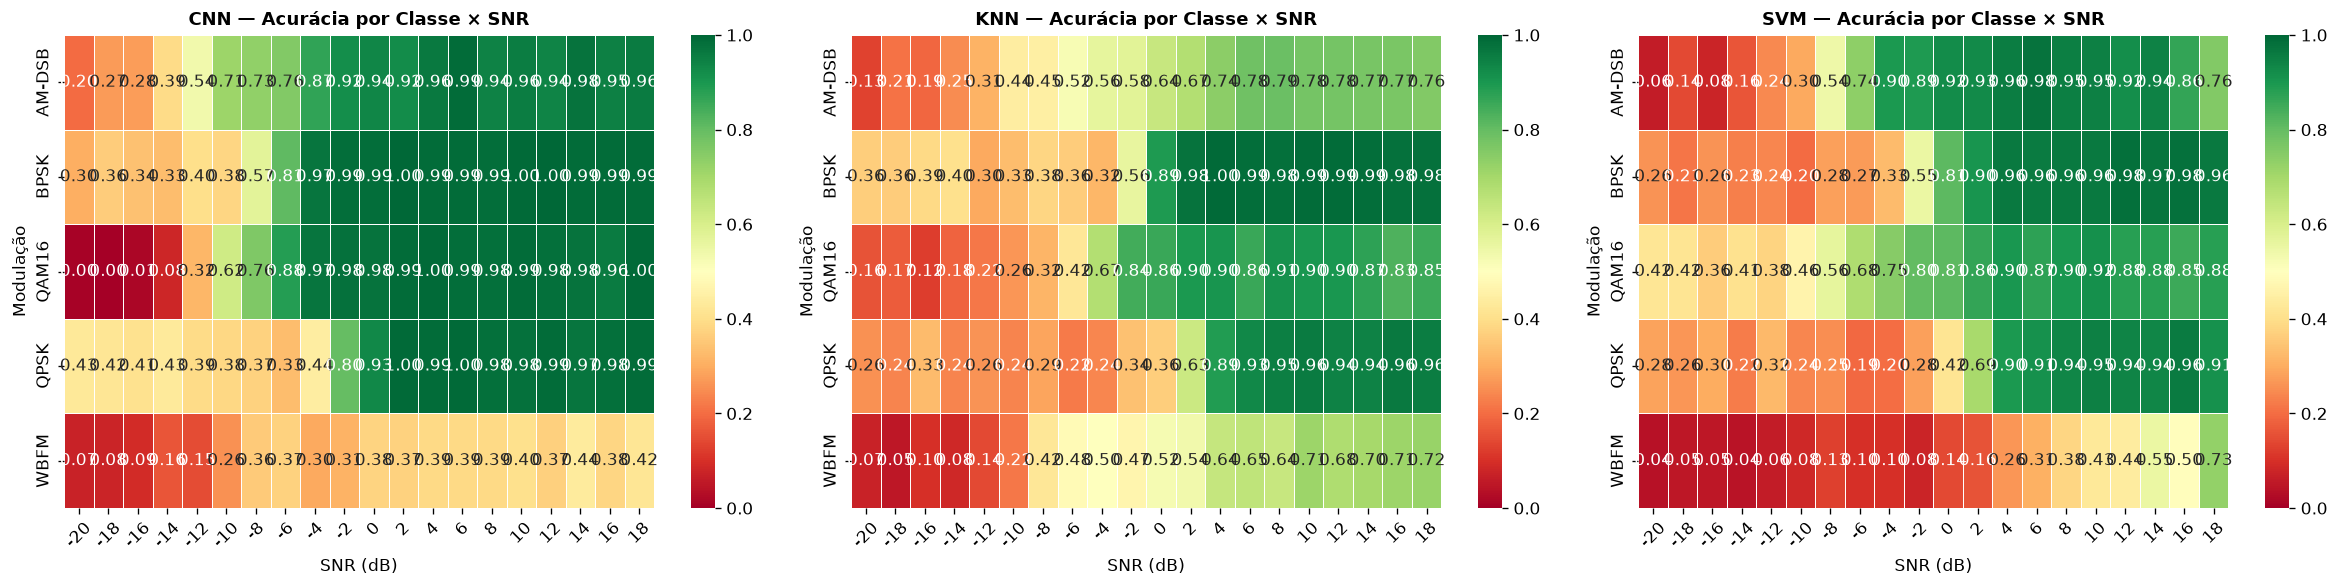

💾 Figura salva: heatmap_class_snr.png


In [25]:
# Heatmap: Acurácia por Classe × SNR — para cada algoritmo
def compute_acc_class_snr(y_true, y_pred, snr_arr, classes, snr_values):
    """Retorna matriz (n_classes × n_snrs) com acurácia por classe e SNR."""
    mat = np.full((len(classes), len(snr_values)), np.nan)
    for j, snr in enumerate(snr_values):
        mask = snr_arr == snr
        if mask.sum() == 0:
            continue
        for i, cls_id in enumerate(range(len(classes))):
            cls_mask = mask & (y_true == cls_id)
            if cls_mask.sum() > 0:
                mat[i, j] = accuracy_score(y_true[cls_mask], y_pred[cls_mask])
    return mat


fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, name, y_pred in zip(axes,
    ['CNN', 'KNN', 'SVM'],
    [y_pred_cnn, y_pred_knn, y_pred_svm]):
    mat = compute_acc_class_snr(y_test, y_pred, snr_test, le.classes_, snr_values)
    sns.heatmap(mat, ax=ax, vmin=0, vmax=1, cmap='RdYlGn',
                xticklabels=snr_values, yticklabels=le.classes_,
                annot=True, fmt='.2f', linewidths=0.3)
    ax.set_title(f'{name} — Acurácia por Classe × SNR', fontsize=11, fontweight='bold')
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Modulação')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_class_snr.png', bbox_inches='tight')
plt.show()
print('💾 Figura salva: heatmap_class_snr.png')

---
## 📌 Referências

- T. O'Shea, J. Hoydis, *An Introduction to Deep Learning for the Physical Layer*, IEEE TCCN, 2017.
- DeepSig Inc. — [RadioML Dataset](https://www.deepsig.ai/datasets)
- Scikit-learn: [https://scikit-learn.org](https://scikit-learn.org)
- TensorFlow/Keras: [https://www.tensorflow.org](https://www.tensorflow.org)
- ONNX Runtime: [https://onnxruntime.ai](https://onnxruntime.ai)

---
*Notebook gerado para experimentos de AMC — RadioML2016.10a | CNN × SVM × KNN*